# Multiphase fitting: FeS and silicates

This notebook fits an illustrative mixed composition against six catalogue phases:

- FeS — listed in the catalogue as **Troilite (FeS)**
- Forsterite (Mg₂SiO₄)
- Fayalite (Fe₂SiO₄)
- Enstatite (Mg₂Si₂O₆)
- Ferrosilite (Fe₂Si₂O₆; sometimes written “ferrisilite”)
- Diopside (MgCaSi₂O₆)

The fitter uses non-negative least squares to obtain phase **formula-unit molar percentages**. This example supplies atomic-percent data directly so that measured oxygen and sulfur are both retained; substitute quantified atomic percentages from an EDS analysis for real data.

## 1. Setup

In [1]:
import os
import sys

os.chdir(os.path.abspath('..'))
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import PhysicsBasics as pb
import StoichiometryCore as core

pd.set_option('display.precision', 4)
pd.set_option('display.width', 120)
print(f'numpy {np.__version__} | pandas {pd.__version__}')

In C:\Users\zsg\.matplotlib\stylelib\scpy.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In C:\Users\zsg\.matplotlib\stylelib\scpy.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


numpy 2.3.5 | pandas 2.3.3


## 2. Select the phase set

Names must exactly match the entries in `ConfigData/Phases.csv`. The formulas below are also used to build a reproducible synthetic mixed composition.

In [2]:
phase_formulae = {
    'Troilite (FeS)': {'Fe': 1, 'S': 1},
    'Forsterite (Mg2SiO4)': {'Mg': 2, 'Si': 1, 'O': 4},
    'Fayalite (Fe2SiO4)': {'Fe': 2, 'Si': 1, 'O': 4},
    'Enstatite (Mg2Si2O6)': {'Mg': 2, 'Si': 2, 'O': 6},
    'Ferrosilite (Fe2Si2O6)': {'Fe': 2, 'Si': 2, 'O': 6},
    'Diopside (MgCaSi2O6)': {'Mg': 1, 'Ca': 1, 'Si': 2, 'O': 6},
}

# Formula-unit amounts used only to construct the example spectrum.
nominal_phase_amounts = {
    'Troilite (FeS)': 9.0,
    'Forsterite (Mg2SiO4)': 14.0,
    'Fayalite (Fe2SiO4)': 17.0,
    'Enstatite (Mg2Si2O6)': 22.0,
    'Ferrosilite (Fe2Si2O6)': 16.0,
    'Diopside (MgCaSi2O6)': 22.0,
}

pd.DataFrame({
    'Catalogue phase': list(phase_formulae),
    'Formula-unit amount': list(nominal_phase_amounts.values()),
    'Formula': [' '.join(f'{element}{amount}' for element, amount in formula.items())
                for formula in phase_formulae.values()],
})

,Catalogue phase,Formula-unit amount,Formula
0,Troilite (FeS),9.0,Fe1 S1
1,Forsterite (Mg2SiO4),14.0,Mg2 Si1 O4
2,Fayalite (Fe2SiO4),17.0,Fe2 Si1 O4
3,Enstatite (Mg2Si2O6),22.0,Mg2 Si2 O6
4,Ferrosilite (Fe2Si2O6),16.0,Fe2 Si2 O6
5,Diopside (MgCaSi2O6),22.0,Mg1 Ca1 Si2 O6


## 3. Create an illustrative atomic-percent composition

For a measured sample, replace this cell with the quantified elemental atomic percentages. Do not use oxygen-by-stoichiometry for this sulfur-bearing multiphase example: oxygen is supplied explicitly.

In [3]:
atom_totals = np.zeros(pb.MAXELEMENT)
for phase, formula_unit_amount in nominal_phase_amounts.items():
    for element, atoms_per_formula_unit in phase_formulae[phase].items():
        element_index = pb.ElementalSymbols.index(element) - 1
        atom_totals[element_index] += formula_unit_amount * atoms_per_formula_unit

input_at_pct = atom_totals / atom_totals.sum() * 100

input_composition = pd.DataFrame([
    {'Element': pb.ElementalSymbols[index + 1], 'Atomic %': value}
    for index, value in enumerate(input_at_pct) if value > 0
])
input_composition

,Element,Atomic %
0,O,57.9641
1,Mg,11.2575
2,Si,18.0838
3,S,1.0778
4,Ca,2.6347
5,Fe,8.9820


## 4. Run the multiphase fit

`selected_phases` restricts the non-negative least-squares fit to the six minerals above. For counts rather than already-quantified atomic percentages, first run the appropriate EDS quantification and pass its atomic-percent composition here.

In [4]:
analysis_input = core.AnalysisInput(
    values=dict(core.vector_to_element_dict(input_at_pct)),
    input_type='At %',
)
options = core.AnalysisOptions(selected_phases=list(phase_formulae))

result = core.run_analysis(analysis_input, options=options)
if result.warnings:
    print('Warnings:', *result.warnings, sep='\n- ')

print(result.report_text)

Input data:
Element             At %
O                 57.964
Mg                11.257
Si                18.084
S                  1.078
Ca                 2.635
Fe                 8.982
Total:           100.000


Quantification results:
Element       At%      Wt%  Ox Wt %  Valence k-factor
O          57.964   39.452    0.000      n/a    1.000
Mg         11.257   11.640    0.000      n/a    1.000
Si         18.084   21.606    0.000      n/a    1.000
S           1.078    1.470    0.000      n/a    1.000
Ca          2.635    4.492    0.000      n/a    1.000
Fe          8.982   21.339    0.000      n/a    1.000

Phase fit results:
Phase                          Molar %
Forsterite (Mg2SiO4)           0.000%
Fayalite (Fe2SiO4)             31.000%
Troilite (FeS)                 9.000%
Enstatite (Mg2Si2O6)           36.000%
Ferrosilite (Fe2Si2O6)         2.000%
Diopside (MgCaSi2O6)           22.000%
Fit residual                   4.0129e-15

Composition of phase fit:
Element      At %
O      

## 5. Inspect phase abundances and reconstructed composition

In [5]:
phase_fit_table = next(table for table in result.tables if table.name == 'phase_fit')
phase_fit = pd.DataFrame(phase_fit_table.rows)
phase_fit.attrs['residual'] = phase_fit_table.metadata['residual']
print(f"Fit residual: {phase_fit.attrs['residual']:.3e}")
phase_fit

Fit residual: 4.013e-15


,phase,formula,molar_pct
0,Forsterite (Mg2SiO4),Mg2 Si1 O4,0.0
1,Fayalite (Fe2SiO4),Fe2 Si1 O4,31.0
2,Troilite (FeS),Fe1 S1,9.0
3,Enstatite (Mg2Si2O6),Mg2 Si2 O6,36.0
4,Ferrosilite (Fe2Si2O6),Fe2 Si2 O6,2.0
5,Diopside (MgCaSi2O6),Mg1 Ca1 Si2 O6,22.0


In [6]:
fit_composition_table = next(table for table in result.tables
                             if table.name == 'phase_fit_composition')
fit_composition = pd.DataFrame(fit_composition_table.rows).rename(
    columns={'element': 'Element', 'at_pct': 'Fitted atomic %'}
)
comparison = input_composition.merge(fit_composition, on='Element', how='outer').fillna(0)
comparison['Difference'] = comparison['Fitted atomic %'] - comparison['Atomic %']
comparison

,Element,Atomic %,Fitted atomic %,Difference
0,Ca,2.6347,2.6347,-4.4409e-16
1,Fe,8.9820,8.9820,1.7764e-15
2,Mg,11.2575,11.2575,-3.5527e-15
3,O,57.9641,57.9641,0.0000e+00
4,S,1.0778,1.0778,1.7764e-15
5,Si,18.0838,18.0838,0.0000e+00


## 6. Important interpretation: this phase set is not unique

The six selected formula vectors span only five independent elemental dimensions (O, Mg, Si, S, Ca, and Fe). Consequently, more than one non-negative combination can reproduce this composition exactly. The fitter reports one valid solution; a zero value for one of the overlapping olivine/pyroxene end members does **not** prove that phase is absent. Independent constraints (additional elements, diffraction, or a reduced phase set) are needed to distinguish the alternatives.

In [7]:
elements = ['O', 'Mg', 'Si', 'S', 'Ca', 'Fe']
formula_matrix = np.array([
    [phase_formulae[phase].get(element, 0.0) for phase in phase_formulae]
    for element in elements
])

print(f'Formula-matrix rank: {np.linalg.matrix_rank(formula_matrix)} of {len(phase_formulae)} selected phases')
pd.DataFrame(formula_matrix, index=elements, columns=phase_formulae)

Formula-matrix rank: 5 of 6 selected phases


,Troilite (FeS),Forsterite (Mg2SiO4),Fayalite (Fe2SiO4),Enstatite (Mg2Si2O6),Ferrosilite (Fe2Si2O6),Diopside (MgCaSi2O6)
O,0.0,4.0,4.0,6.0,6.0,6.0
Mg,0.0,2.0,0.0,2.0,0.0,1.0
Si,0.0,1.0,1.0,2.0,2.0,2.0
S,1.0,0.0,0.0,0.0,0.0,0.0
Ca,0.0,0.0,0.0,0.0,0.0,1.0
Fe,1.0,0.0,2.0,0.0,2.0,0.0


## 7. Plot the locus of non-negative solutions

The final right-singular vector of the formula matrix is its one-dimensional null space. Moving along that vector leaves the reconstructed elemental composition (and therefore the residual) unchanged. The bounds below stop exactly where a phase abundance reaches zero.

Feasible locus: t = 0.000 to 31.000 molar %
Maximum elemental change along locus: 7.11e-14


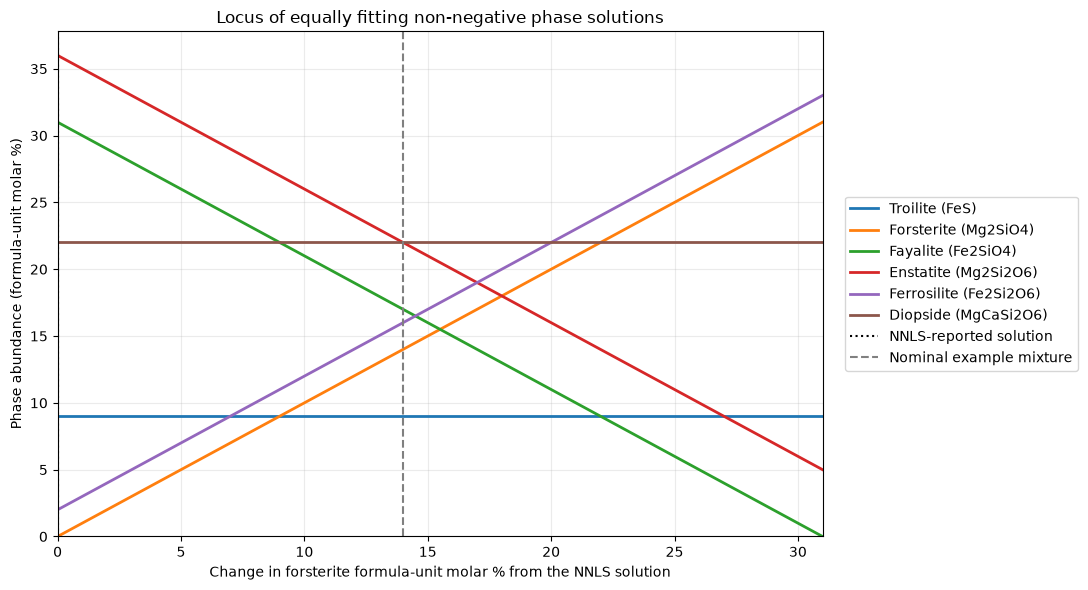

In [8]:
phase_names = list(phase_formulae)
fitted_phase_pct = (phase_fit.set_index('phase')
                   .reindex(phase_names)['molar_pct'].to_numpy(dtype=float))

# The rank-deficient direction is scaled so one unit of t adds one molar % forsterite.
_, _, right_singular_vectors = np.linalg.svd(formula_matrix)
null_direction = right_singular_vectors[-1]
forsterite_index = phase_names.index('Forsterite (Mg2SiO4)')
if null_direction[forsterite_index] < 0:
    null_direction *= -1
null_direction /= null_direction[forsterite_index]

# Find the interval for which every phase abundance remains non-negative.
t_min, t_max = -np.inf, np.inf
for abundance, slope in zip(fitted_phase_pct, null_direction):
    if slope > 1e-12:
        t_min = max(t_min, -abundance / slope)
    elif slope < -1e-12:
        t_max = min(t_max, -abundance / slope)

# Remove numerical noise at a boundary (for this example, the NNLS solution has 0% forsterite).
if abs(t_min) < 1e-12:
    t_min = 0.0
if abs(t_max) < 1e-12:
    t_max = 0.0

t_values = np.linspace(t_min, t_max, 300)
solution_locus = fitted_phase_pct + np.outer(t_values, null_direction)
reconstruction_change = formula_matrix @ (solution_locus - fitted_phase_pct).T
print(f'Feasible locus: t = {t_min:.3f} to {t_max:.3f} molar %')
print(f'Maximum elemental change along locus: {np.abs(reconstruction_change).max():.2e}')

fig, ax = plt.subplots(figsize=(11, 6))
for phase, phase_values in zip(phase_names, solution_locus.T):
    ax.plot(t_values, phase_values, linewidth=2, label=phase)

ax.axvline(0, color='black', linestyle=':', linewidth=1.5, label='NNLS-reported solution')
nominal_pct = np.array([nominal_phase_amounts[phase] for phase in phase_names], dtype=float)
nominal_t = np.dot(nominal_pct - fitted_phase_pct, null_direction) / np.dot(null_direction, null_direction)
if t_min - 1e-8 <= nominal_t <= t_max + 1e-8:
    ax.axvline(nominal_t, color='gray', linestyle='--', linewidth=1.5,
               label='Nominal example mixture')

ax.set_xlabel('Change in forsterite formula-unit molar % from the NNLS solution')
ax.set_ylabel('Phase abundance (formula-unit molar %)')
ax.set_title('Locus of equally fitting non-negative phase solutions')
ax.set_xlim(t_min, t_max)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()

The plot makes the ambiguity concrete: increasing forsterite requires equal compensating changes in fayalite, enstatite, and ferrosilite. Troilite and diopside stay fixed because sulfur and calcium independently constrain them. Every point on the displayed segment gives the same elemental reconstruction; only its endpoints are limited by the non-negativity requirement.

### Why six elements do not give a unique six-phase fit

Six measured elements and six candidate phases allow a unique solution only when the six phase-composition vectors are **linearly independent**. 

For the four Mg–Fe silicate endmembers in this fit, the dependency is:

$\mathrm{Forsterite} + \mathrm{Ferrosilite}
= \mathrm{Fayalite} + \mathrm{Enstatite}$

$\mathrm{Mg_2SiO_4} + \mathrm{Fe_2Si_2O_6}
= \mathrm{Fe_2SiO_4} + \mathrm{Mg_2Si_2O_6}
= \mathrm{Mg_2Fe_2Si_3O_{10}}$.

Equivalently, the phase matrix has the null-space direction

$+\mathrm{Forsterite} - \mathrm{Fayalite}
- \mathrm{Enstatite} + \mathrm{Ferrosilite} = 0$

Moving by any allowed amount along this direction preserves Mg, Fe, Si, and O. Its coefficients also sum to zero, so the total formula-unit fraction is preserved. Sulfur fixes troilite and calcium fixes diopside, but neither supplies information that separates these four silicate endmembers. The resulting six-column phase matrix therefore has rank 5, yielding the one-dimensional locus plotted above.

## 8. Using measured data

Replace `input_at_pct` with your measured, quantified atomic-percent vector and keep `selected_phases` limited to phases supported by independent evidence. Review both the residual and the reconstructed elemental composition before interpreting phase fractions. The reported percentages are formula-unit molar percentages, not weight percentages.